Part 1 — Deep Exploratory Analysis & Feature Engineering

1. Load the dataset and re-examine its structure.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Paste your copied path here
path = '/content/drive/MyDrive/Steel_industry_data.csv'
df = pd.read_csv(path)

In [ ]:
print("--- Dataset Info ---")
df.info()
print("\n--- First 5 Rows ---")
df.head()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


2. Convert the date column to datetime and extract: hour of day, day of week, month, and whether
the day is a weekday or weekend — add these as new columns.

In [ ]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

# Extract datetime components
df['hour_of_day'] = df['date'].dt.hour
df['extracted_day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# Create binary weekday vs weekend feature (5 and 6 correspond to Saturday and Sunday)
df['is_weekend'] = df['extracted_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print(df[['date', 'hour_of_day', 'extracted_day_of_week', 'month', 'is_weekend']].head())

                 date  hour_of_day  extracted_day_of_week  month  is_weekend
0 2018-01-01 00:15:00            0                      0      1           0
1 2018-01-01 00:30:00            0                      0      1           0
2 2018-01-01 00:45:00            0                      0      1           0
3 2018-01-01 01:00:00            1                      0      1           0
4 2018-01-01 01:15:00            1                      0      1           0


3. Create a new feature called Power Factor Ratio by dividing leading power factor by lagging
power factor.

In [ ]:
# Calculate the Power Factor Ratio using exact column names
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']

print(df[['Leading_Current_Power_Factor', 'Lagging_Current_Power_Factor', 'Power_Factor_Ratio']].head())

   Leading_Current_Power_Factor  Lagging_Current_Power_Factor  \
0                         100.0                         73.21   
1                         100.0                         66.77   
2                         100.0                         70.28   
3                         100.0                         68.09   
4                         100.0                         64.72   

   Power_Factor_Ratio  
0            1.365934  
1            1.497679  
2            1.422880  
3            1.468644  
4            1.545117  


4. Create a new binary feature called High Load by marking rows where Usage kWh is above the
75th percentile as 1 and the rest as 0.

In [ ]:
# Determine the 75th percentile of Usage_kWh
q75_usage = df['Usage_kWh'].quantile(0.75)

# Mark rows above 75th percentile as 1, otherwise 0
df['High_Load'] = (df['Usage_kWh'] > q75_usage).astype(int)

print(f"75th Percentile Threshold: {q75_usage}")
print(df['High_Load'].value_counts())

75th Percentile Threshold: 51.2375
High_Load
0    26280
1     8760
Name: count, dtype: int64


5. Detect outliers in Usage kWh using the IQR method — print how many outliers exist and
visualize them with a boxplot.

Number of outliers detected in Usage_kWh: 328


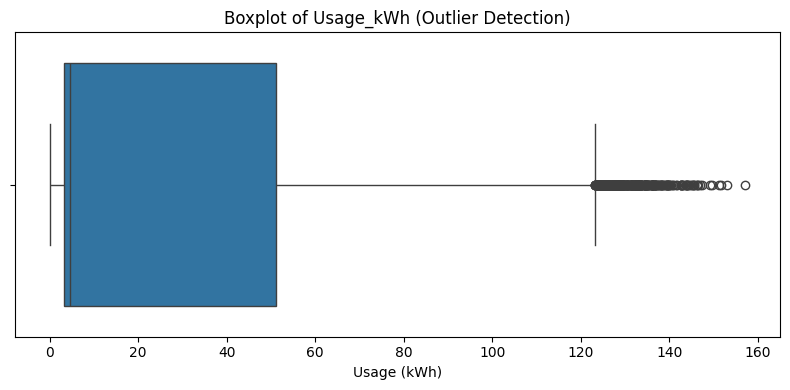

In [ ]:
# Calculate IQR for Usage_kWh
q25 = df['Usage_kWh'].quantile(0.25)
q75 = df['Usage_kWh'].quantile(0.75)
iqr = q75 - q25

lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr

# Identify outliers
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
print(f"Number of outliers detected in Usage_kWh: {len(outliers)}")

# Visualize with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage_kWh'])
plt.title('Boxplot of Usage_kWh (Outlier Detection)')
plt.xlabel('Usage (kWh)')
plt.tight_layout()
plt.show()

6. Plot a correlation heatmap of all numerical features and identify the top 3 features most correlated
with Usage kWh.

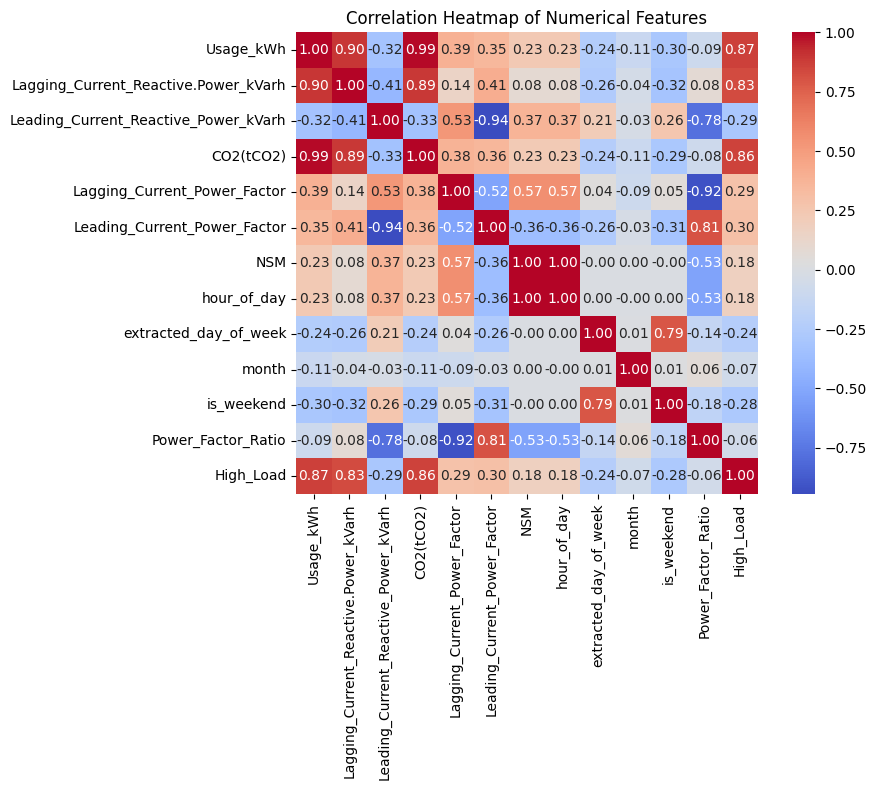

Top 3 features most correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Load                               0.86784
Name: Usage_kWh, dtype: float64


In [ ]:
# Filter for only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

# Identify top 3 features most correlated with Usage_kWh (excluding itself)
top_corr = corr_matrix['Usage_kWh'].abs().sort_values(ascending=False)
print("Top 3 features most correlated with Usage_kWh:")
print(top_corr.iloc[1:4])

7. Create a grouped bar chart showing average energy consumption by Load Type (Light Load,
Medium Load, Maximum Load).

/tmp/ipykernel_844/1406863287.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_load, x='Load_Type', y='Usage_kWh', palette='viridis', order=['Light_Load', 'Medium_Load', 'Maximum_Load'])


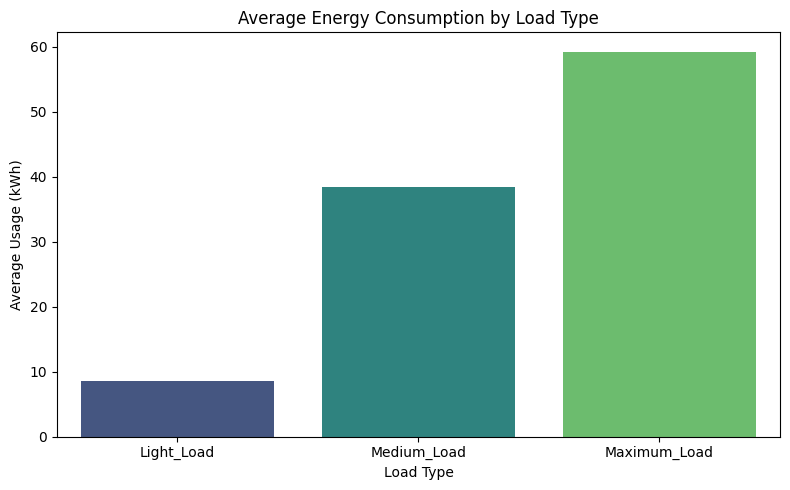

In [ ]:
# Calculate average energy consumption grouped by Load_Type
avg_load = df.groupby('Load_Type')['Usage_kWh'].mean().reset_index()

# Plot the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_load, x='Load_Type', y='Usage_kWh', palette='viridis', order=['Light_Load', 'Medium_Load', 'Maximum_Load'])
plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage (kWh)')
plt.tight_layout()
plt.show()

8. Create a line chart showing average energy usage by hour of day.

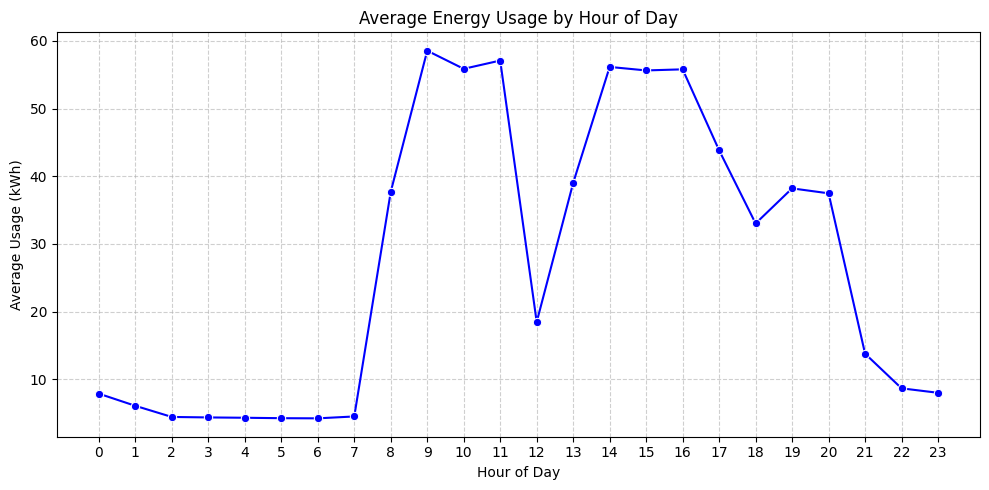

In [ ]:
# Calculate average energy usage grouped by hour of day
avg_hourly = df.groupby('hour_of_day')['Usage_kWh'].mean().reset_index()

# Plot the line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_hourly, x='hour_of_day', y='Usage_kWh', marker='o', color='b')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

9. Write a 250-word EDA Summary at the end covering: data quality issues found, top correlated
features, the most interesting pattern discovered, and one hypothesis about what drives energy
spikes.

## EDA Summary

### Data Quality Issues

The initial data inspection revealed one significant data quality issue: the `date` column was imported as an object type and its format ('Day/Month/Year Hour:Minute') required explicit specification during conversion to datetime. This was resolved by using `pd.to_datetime` with `format='%d/%m/%Y %H:%M'`. No other major missing values or inconsistent data types were immediately apparent across the dataset, as all columns showed 35040 non-null entries.

### Top Correlated Features

The correlation heatmap and subsequent analysis identified the top 3 features most correlated with `Usage_kWh` (energy consumption):

1.  **CO2(tCO2)** (Correlation: 0.988): This is the strongest correlation, indicating a very direct relationship between energy usage and CO2 emissions, as expected.
2.  **Lagging_Current_Reactive.Power_kVarh** (Correlation: 0.896): This feature also shows a strong positive correlation, suggesting that higher reactive power consumption (lagging) is closely tied to higher active energy usage.
3.  **High_Load** (Correlation: 0.868): The binary 'High_Load' feature, indicating usage above the 75th percentile, naturally has a high correlation, confirming its effectiveness in identifying periods of high consumption.

### Most Interesting Pattern Discovered

The line chart showing average energy usage by hour of day revealed a very distinct pattern. Energy consumption is lowest in the early morning hours (1 AM to 7 AM), then sharply increases around 8 AM, peaks significantly in the afternoon (around 2 PM to 5 PM), and then gradually declines, with a secondary, smaller peak in the evening before falling again. This pattern strongly suggests a daily operational cycle.

### Hypothesis about Energy Spikes

**Hypothesis:** Energy spikes are primarily driven by production shifts or periods of high operational activity within the steel industry plant. The sharp increase in `Usage_kWh` starting around 8 AM and sustaining high levels throughout the workday until late afternoon (as seen in the hourly usage plot) aligns with typical industrial work schedules. This is further supported by the high correlation with `Load_Type` categories, where 'Maximum_Load' corresponds to significantly higher average usage. Therefore, energy spikes are likely tied to the commencement and sustained operation of heavy machinery and processes during core working hours.

**Save Engineered Dataset for Notebook 2**

In [ ]:
# Save the engineered dataframe to a CSV file so it can be picked up by the modeling notebook
df.to_csv("steel_industry_engineered.csv", index=False)
print("Engineered dataset successfully saved as 'steel_industry_engineered.csv'.")

Engineered dataset successfully saved as 'steel_industry_engineered.csv'.
